# Compas Racial Bias

## About the dataset

### Context

COMPAS (Correctional Offender Management Profiling for Alternative Sanctions) is a popular commercial algorithm used by judges and parole officers for scoring
criminal defendant’s likelihood of reoffending (recidivism). It has been shown that the algorithm is biased in favor of white defendants, and against black inmates,
based on a 2 year follow up study (i.e who actually committed crimes or violent crimes after 2 years). The pattern of mistakes, as measured by precision/sensitivity
is notable.

Quoting from ProPublica:
```
Black defendants were often predicted to be at a higher risk of recidivism than they actually were. Our analysis found that black defendants who did not recidivate
over a two-year period were nearly twice as likely to be misclassified as higher risk compared to their white counterparts (45 percent vs. 23 percent). White
defendants were often predicted to be less risky than they were. Our analysis found that white defendants who re-offended within the next two years were mistakenly
labeled low risk almost twice as often as black re-offenders (48 percent vs. 28 percent). The analysis also showed that even when controlling for prior crimes,
future recidivism, age, and gender, black defendants were 45 percent more likely to be assigned higher risk scores than white defendants.
```
- Black defendants were also twice as likely as white defendants to be misclassified as being a higher risk of violent recidivism. And white violent recidivists were 63 percent more likely to have been misclassified as a low risk of violent recidivism, compared with black violent recidivists.
- The violent recidivism analysis also showed that even when controlling for prior crimes, future recidivism, age, and gender, black defendants were 77 percent more likely to be assigned higher risk scores than white defendants.

### Content

Data contains variables used by the COMPAS algorithm in scoring defendants, along with their outcomes within 2 years of the decision, for over 10,000 criminal
defendants in Broward County, Florida. 3 subsets of the data are provided, including a subset of only violent recividism (as opposed to, e.g. being reincarcerated
for non violent offenses such as vagrancy or Marijuana).

Indepth analysis by ProPublica can be found in their [data methodology article](https://www.propublica.org/article/how-we-analyzed-the-compas-recidivism-algorithm).

### Inspiration

Ideas:
   - Feature importance when predicting the COMPASS score itself, or recividism/crime risks.
   - Reweighting data to compensate for bias, e.g. subsetting for the violent offenders, or adjusting better for base risk.
   - Feature selection based on "legal usage"/fairness (E.g. exclude race and see how well your model works. It worked for me).


In [48]:
# imports
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from pygments.lexer import include
import warnings
# warnings.filterwarnings('ignore')

### Read in the data

In [49]:
compas_df = pd.read_csv('../data/compas_racial_bias/compas-scores-raw.csv')
compas_df.head()

,Person_ID,AssessmentID,Case_ID,Agency_Text,LastName,FirstName,MiddleName,Sex_Code_Text,Ethnic_Code_Text,DateOfBirth,...,RecSupervisionLevel,RecSupervisionLevelText,Scale_ID,DisplayText,RawScore,DecileScore,ScoreText,AssessmentType,IsCompleted,IsDeleted
0,50844,57167,51950,PRETRIAL,Fisher,Kevin,NaN,Male,Caucasian,12/05/92,...,1,Low,7,Risk of Violence,-2.08,4,Low,New,1,0
1,50844,57167,51950,PRETRIAL,Fisher,Kevin,NaN,Male,Caucasian,12/05/92,...,1,Low,8,Risk of Recidivism,-1.06,2,Low,New,1,0
2,50844,57167,51950,PRETRIAL,Fisher,Kevin,NaN,Male,Caucasian,12/05/92,...,1,Low,18,Risk of Failure to Appear,15.00,1,Low,New,1,0
3,50848,57174,51956,PRETRIAL,KENDALL,KEVIN,NaN,Male,Caucasian,09/16/84,...,1,Low,7,Risk of Violence,-2.84,2,Low,New,1,0
4,50848,57174,51956,PRETRIAL,KENDALL,KEVIN,NaN,Male,Caucasian,09/16/84,...,1,Low,8,Risk of Recidivism,-1.50,1,Low,New,1,0


In [50]:
compas_df.dtypes

Person_ID                    int64
AssessmentID                 int64
Case_ID                      int64
Agency_Text                 object
LastName                    object
FirstName                   object
MiddleName                  object
Sex_Code_Text               object
Ethnic_Code_Text            object
DateOfBirth                 object
ScaleSet_ID                  int64
ScaleSet                    object
AssessmentReason            object
Language                    object
LegalStatus                 object
CustodyStatus               object
MaritalStatus               object
Screening_Date              object
RecSupervisionLevel          int64
RecSupervisionLevelText     object
Scale_ID                     int64
DisplayText                 object
RawScore                   float64
DecileScore                  int64
ScoreText                   object
AssessmentType              object
IsCompleted                  int64
IsDeleted                    int64
dtype: object

In [51]:
null_summary = pd.DataFrame({
    'Null Count': compas_df.isnull().sum(),
    'Percentage': (compas_df.isnull().sum() / len(compas_df)) * 100
})
null_summary

,Null Count,Percentage
Person_ID,0,0.000000
AssessmentID,0,0.000000
Case_ID,0,0.000000
Agency_Text,0,0.000000
LastName,0,0.000000
FirstName,0,0.000000
MiddleName,45219,74.320793
Sex_Code_Text,0,0.000000
Ethnic_Code_Text,0,0.000000
DateOfBirth,0,0.000000


### Convert colums to relavent data types
#### Datatime columns

In [52]:
# date of birth
compas_df = compas_df.astype({'DateOfBirth': 'datetime64[ns]', 'Screening_Date': 'datetime64[ns]'})
compas_df[['DateOfBirth', "Screening_Date"]].dtypes

DateOfBirth       datetime64[ns]
Screening_Date    datetime64[ns]
dtype: object

#### Encoding Text
Excluding names because those are irrelivent

In [53]:
compas_df.select_dtypes(include= 'object').nunique()

Agency_Text                    4
LastName                   10896
FirstName                   7225
MiddleName                  1870
Sex_Code_Text                  2
Ethnic_Code_Text               9
ScaleSet                       2
AssessmentReason               1
Language                       2
LegalStatus                    7
CustodyStatus                  6
MaritalStatus                  7
RecSupervisionLevelText        4
DisplayText                    3
ScoreText                      3
AssessmentType                 2
dtype: int64

In [54]:
# feature to one hot encoding
one_hot_features = ['Sex_Code_Text', 'Ethnic_Code_Text','Language', 'LegalStatus','CustodyStatus', 'MaritalStatus', 'DisplayText']
for feature in one_hot_features:
    print(compas_df[feature].unique())

def replace_with_one_hot(df, columns):
    # One-hot encode selected columns
    dummies = pd.get_dummies(df[columns],prefix="", prefix_sep="", drop_first=False)
    # Drop original columns
    df = df.drop(columns=columns)
    # Add new encoded columns
    df = pd.concat([df, dummies], axis=1)
    return df
compas_df = replace_with_one_hot(compas_df, one_hot_features)
compas_df.head()

['Male' 'Female']
['Caucasian' 'African-American' 'Hispanic' 'Other' 'Asian' 'African-Am'
 'Native American' 'Oriental' 'Arabic']
['English' 'Spanish']
['Pretrial' 'Post Sentence' 'Conditional Release' 'Other'
 'Probation Violator' 'Parole Violator' 'Deferred Sentencing']
['Jail Inmate' 'Probation' 'Pretrial Defendant' 'Residential Program'
 'Prison Inmate' 'Parole']
['Single' 'Married' 'Significant Other' 'Divorced' 'Separated' 'Widowed'
 'Unknown']
['Risk of Violence' 'Risk of Recidivism' 'Risk of Failure to Appear']


,Person_ID,AssessmentID,Case_ID,Agency_Text,LastName,FirstName,MiddleName,DateOfBirth,ScaleSet_ID,ScaleSet,...,Divorced,Married,Separated,Significant Other,Single,Unknown,Widowed,Risk of Failure to Appear,Risk of Recidivism,Risk of Violence
0,50844,57167,51950,PRETRIAL,Fisher,Kevin,NaN,1992-12-05,22,Risk and Prescreen,...,False,False,False,False,True,False,False,False,False,True
1,50844,57167,51950,PRETRIAL,Fisher,Kevin,NaN,1992-12-05,22,Risk and Prescreen,...,False,False,False,False,True,False,False,False,True,False
2,50844,57167,51950,PRETRIAL,Fisher,Kevin,NaN,1992-12-05,22,Risk and Prescreen,...,False,False,False,False,True,False,False,True,False,False
3,50848,57174,51956,PRETRIAL,KENDALL,KEVIN,NaN,1984-09-16,22,Risk and Prescreen,...,False,True,False,False,False,False,False,False,False,True
4,50848,57174,51956,PRETRIAL,KENDALL,KEVIN,NaN,1984-09-16,22,Risk and Prescreen,...,False,True,False,False,False,False,False,False,True,False


In [55]:
compas_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60843 entries, 0 to 60842
Data columns (total 57 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Person_ID                  60843 non-null  int64         
 1   AssessmentID               60843 non-null  int64         
 2   Case_ID                    60843 non-null  int64         
 3   Agency_Text                60843 non-null  object        
 4   LastName                   60843 non-null  object        
 5   FirstName                  60843 non-null  object        
 6   MiddleName                 15624 non-null  object        
 7   DateOfBirth                60843 non-null  datetime64[ns]
 8   ScaleSet_ID                60843 non-null  int64         
 9   ScaleSet                   60843 non-null  object        
 10  AssessmentReason           60843 non-null  object        
 11  Screening_Date             60843 non-null  datetime64[ns]
 12  RecS

In [56]:
#convert boolean to int
compas_df.select_dtypes(include='bool').replace({True:1, False:0})

,Female,Male,African-Am,African-American,Arabic,Asian,Caucasian,Hispanic,Native American,Oriental,...,Divorced,Married,Separated,Significant Other,Single,Unknown,Widowed,Risk of Failure to Appear,Risk of Recidivism,Risk of Violence
0,0,1,0,0,0,0,1,0,0,0,...,0,0,0,0,1,0,0,0,0,1
1,0,1,0,0,0,0,1,0,0,0,...,0,0,0,0,1,0,0,0,1,0
2,0,1,0,0,0,0,1,0,0,0,...,0,0,0,0,1,0,0,1,0,0
3,0,1,0,0,0,0,1,0,0,0,...,0,1,0,0,0,0,0,0,0,1
4,0,1,0,0,0,0,1,0,0,0,...,0,1,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60838,0,1,0,1,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,1,0
60839,0,1,0,1,0,0,0,0,0,0,...,0,0,0,0,1,0,0,1,0,0
60840,0,1,0,0,0,0,1,0,0,0,...,0,0,0,0,1,0,0,0,0,1
60841,0,1,0,0,0,0,1,0,0,0,...,0,0,0,0,1,0,0,0,1,0


In [57]:
# create age feature and drop  birth and screeening date
def create_age_column(df, dob_col="DateOfBirth", rec_col="Screening_Date", new_col="Age"):
    dob = df[dob_col]
    rec = df[rec_col]
    # Base age
    age = rec.dt.year - dob.dt.year

    #Subtract 1 when birthday hasn't occurred yet
    birthday_not_happened = (
        (rec.dt.month < dob.dt.month) |
        ((rec.dt.month == dob.dt.month) & (rec.dt.day < dob.dt.day))
    )

    age -= birthday_not_happened.astype(int)
    df[new_col] = np.abs(age)
    return df

compas_df = create_age_column(compas_df, dob_col="DateOfBirth", rec_col="Screening_Date")
compas_df.drop(columns=["DateOfBirth","Screening_Date"], inplace=True)

In [58]:
compas_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60843 entries, 0 to 60842
Data columns (total 56 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Person_ID                  60843 non-null  int64  
 1   AssessmentID               60843 non-null  int64  
 2   Case_ID                    60843 non-null  int64  
 3   Agency_Text                60843 non-null  object 
 4   LastName                   60843 non-null  object 
 5   FirstName                  60843 non-null  object 
 6   MiddleName                 15624 non-null  object 
 7   ScaleSet_ID                60843 non-null  int64  
 8   ScaleSet                   60843 non-null  object 
 9   AssessmentReason           60843 non-null  object 
 10  RecSupervisionLevel        60843 non-null  int64  
 11  RecSupervisionLevelText    60843 non-null  object 
 12  Scale_ID                   60843 non-null  int64  
 13  RawScore                   60843 non-null  flo

Drop all object dtypes columns

In [59]:
compas_df.drop(columns= compas_df.select_dtypes(include='object'), inplace=True)
compas_df

,Person_ID,AssessmentID,Case_ID,ScaleSet_ID,RecSupervisionLevel,Scale_ID,RawScore,DecileScore,IsCompleted,IsDeleted,...,Married,Separated,Significant Other,Single,Unknown,Widowed,Risk of Failure to Appear,Risk of Recidivism,Risk of Violence,Age
0,50844,57167,51950,22,1,7,-2.08,4,1,0,...,False,False,False,True,False,False,False,False,True,20
1,50844,57167,51950,22,1,8,-1.06,2,1,0,...,False,False,False,True,False,False,False,True,False,20
2,50844,57167,51950,22,1,18,15.00,1,1,0,...,False,False,False,True,False,False,True,False,False,20
3,50848,57174,51956,22,1,7,-2.84,2,1,0,...,True,False,False,False,False,False,False,False,True,28
4,50848,57174,51956,22,1,8,-1.50,1,1,0,...,True,False,False,False,False,False,False,True,False,28
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60838,65667,79665,72038,22,3,8,0.16,8,1,0,...,False,False,False,True,False,False,False,True,False,50
60839,65667,79665,72038,22,3,18,35.00,10,1,0,...,False,False,False,True,False,False,True,False,False,50
60840,68603,79669,72042,22,1,7,-2.75,2,1,0,...,False,False,False,True,False,False,False,False,True,29
60841,68603,79669,72042,22,1,8,-0.34,5,1,0,...,False,False,False,True,False,False,False,True,False,29


array([[<Axes: xlabel='Person_ID', ylabel='Person_ID'>,
        <Axes: xlabel='AssessmentID', ylabel='Person_ID'>,
        <Axes: xlabel='Case_ID', ylabel='Person_ID'>,
        <Axes: xlabel='ScaleSet_ID', ylabel='Person_ID'>,
        <Axes: xlabel='RecSupervisionLevel', ylabel='Person_ID'>,
        <Axes: xlabel='Scale_ID', ylabel='Person_ID'>,
        <Axes: xlabel='RawScore', ylabel='Person_ID'>,
        <Axes: xlabel='DecileScore', ylabel='Person_ID'>,
        <Axes: xlabel='IsCompleted', ylabel='Person_ID'>,
        <Axes: xlabel='IsDeleted', ylabel='Person_ID'>,
        <Axes: xlabel='Age', ylabel='Person_ID'>],
       [<Axes: xlabel='Person_ID', ylabel='AssessmentID'>,
        <Axes: xlabel='AssessmentID', ylabel='AssessmentID'>,
        <Axes: xlabel='Case_ID', ylabel='AssessmentID'>,
        <Axes: xlabel='ScaleSet_ID', ylabel='AssessmentID'>,
        <Axes: xlabel='RecSupervisionLevel', ylabel='AssessmentID'>,
        <Axes: xlabel='Scale_ID', ylabel='AssessmentID'>,
        

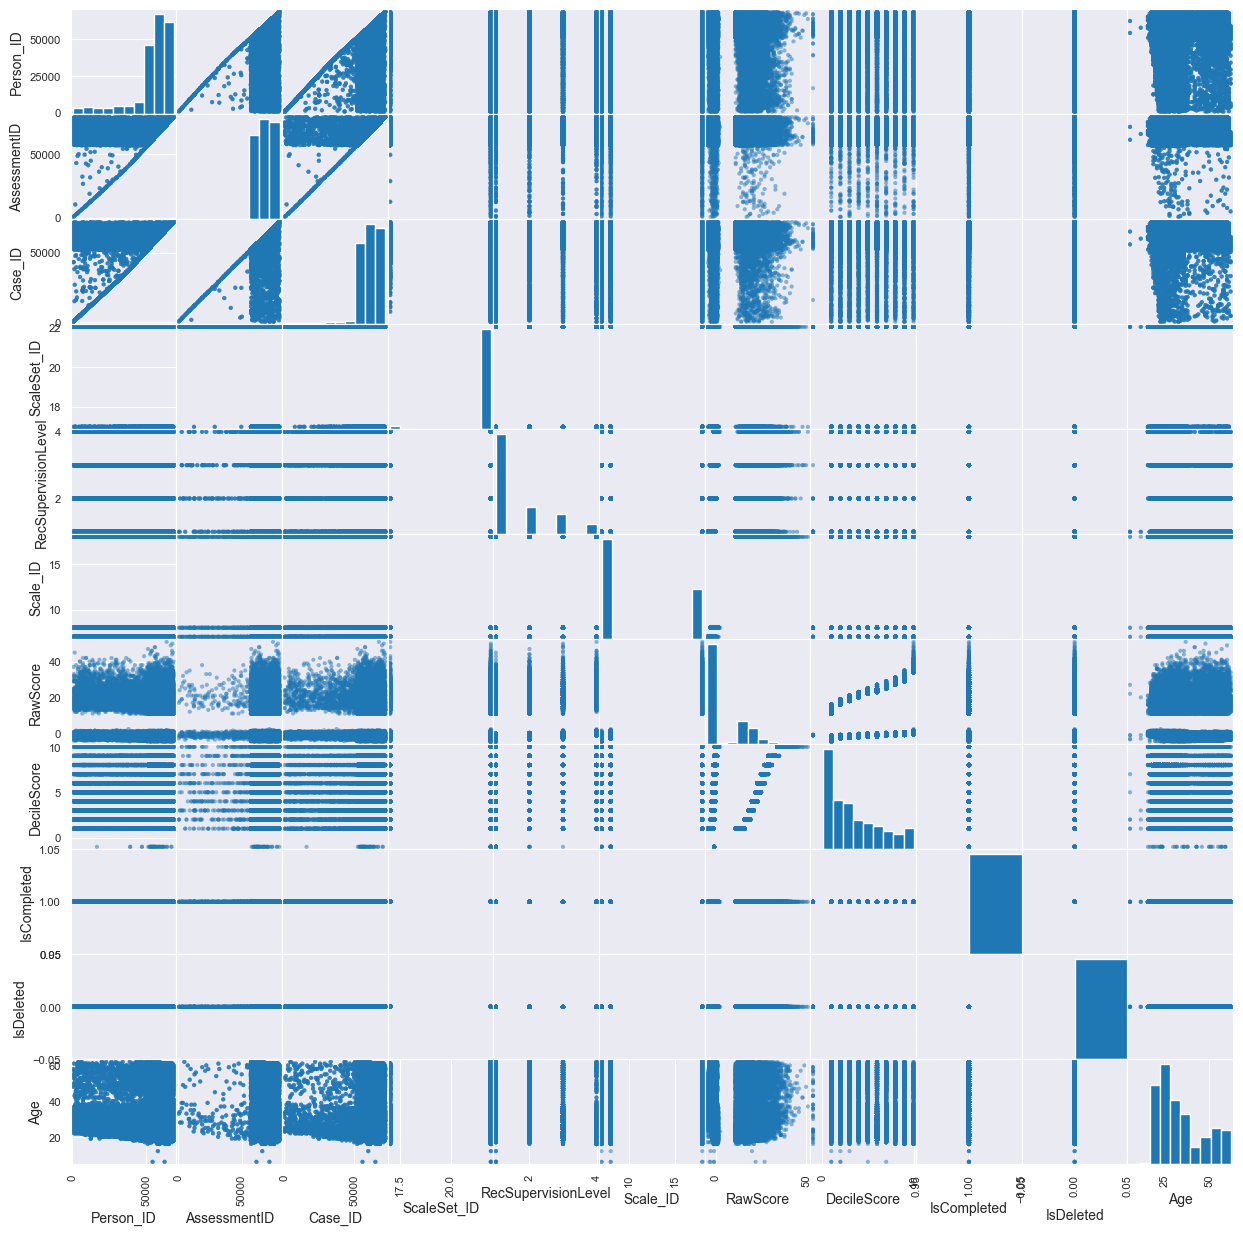

In [60]:
sex_list =['Male', 'Female']
race_list=['Caucasian','African-American', 'Hispanic', 'Other', 'Asian', 'African-Am', 'Native American', 'Oriental', 'Arabic']
language_list =['English', 'Spanish']
legal_status_list=['Pretrial', 'Post Sentence', 'Conditional Release', 'Other', 'Probation Violator', 'Parole Violator', 'Deferred Sentencing']
custody_status_list =['Jail Inmate', 'Probation', 'Pretrial Defendant', 'Residential Program','Prison Inmate', 'Parole']
marital_status_list=['Single' 'Married', 'Significant Other', 'Divorced', 'Separated', 'Widowed','Unknown']
display_list =['Risk of Violence', 'Risk of Recidivism', 'Risk of Failure to Appear']

pd.plotting.scatter_matrix(compas_df.select_dtypes(include=['int64','int32','float64']), figsize=(15,15))
# compas_df.info()

#### outlier detection

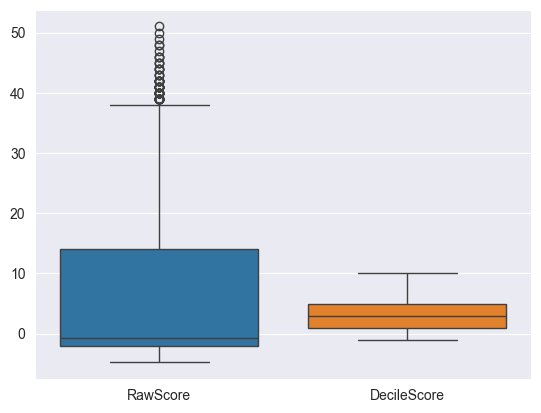

In [61]:
sns.boxplot(compas_df[['RawScore', 'DecileScore']])
plt.show()

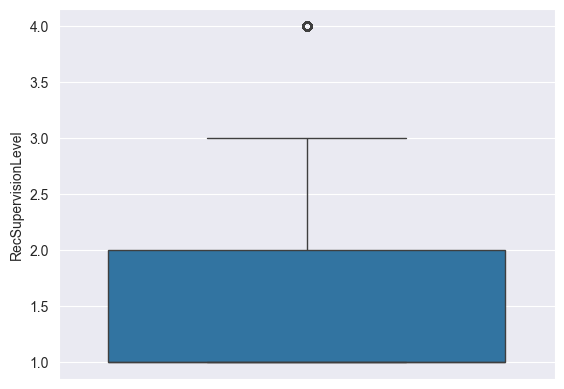

In [62]:
sns.boxplot(compas_df["RecSupervisionLevel"])
plt.show()

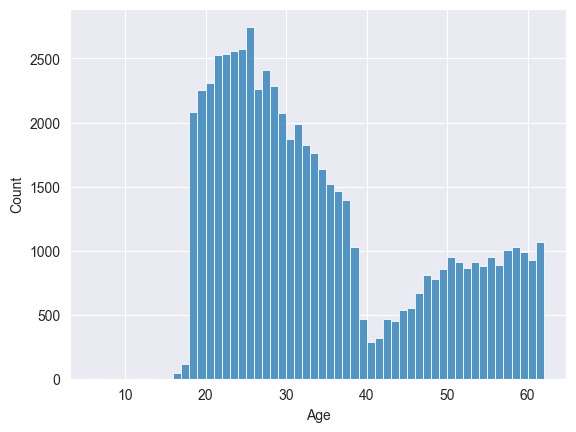

In [63]:
sns.histplot(compas_df, x='Age')
plt.show()

In [64]:
def handle_outliers(df, columns, method="cap", factor=1.5):
    df = df.copy()
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - factor * IQR
        upper = Q3 + factor * IQR
        if method == "cap": # cap values at IQR bounds
            df[col] = df[col].clip(lower, upper)
        elif method == "remove": # remove rows containing outliers
            df = df[(df[col] >= lower) & (df[col] <= upper)]
        elif method == "median": # replace outliers with the column median
            median = df[col].median()
            df.loc[(df[col] < lower) | (df[col] > upper), col] = median
        else:
            raise ValueError("method must be 'cap', 'remove', or 'median'.")
    return df

In [65]:
compas_df =handle_outliers(compas_df, columns=["RawScore"])

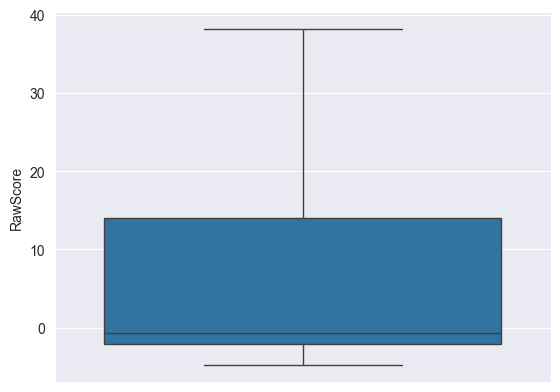

In [66]:
sns.boxplot(compas_df["RawScore"])
plt.show()

#### Normalise values

In [67]:
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler

In [68]:
scalar = StandardScaler()
robust = RobustScaler()
minmax = MinMaxScaler()

In [69]:
compas_df[['DecileScore', 'RecSupervisionLevel']] = scalar.fit_transform(compas_df[['DecileScore','RecSupervisionLevel']])

In [70]:
compas_df

,Person_ID,AssessmentID,Case_ID,ScaleSet_ID,RecSupervisionLevel,Scale_ID,RawScore,DecileScore,IsCompleted,IsDeleted,...,Married,Separated,Significant Other,Single,Unknown,Widowed,Risk of Failure to Appear,Risk of Recidivism,Risk of Violence,Age
0,50844,57167,51950,22,-0.667274,7,-2.08,0.163608,1,0,...,False,False,False,True,False,False,False,False,True,20
1,50844,57167,51950,22,-0.667274,8,-1.06,-0.600383,1,0,...,False,False,False,True,False,False,False,True,False,20
2,50844,57167,51950,22,-0.667274,18,15.00,-0.982378,1,0,...,False,False,False,True,False,False,True,False,False,20
3,50848,57174,51956,22,-0.667274,7,-2.84,-0.600383,1,0,...,True,False,False,False,False,False,False,False,True,28
4,50848,57174,51956,22,-0.667274,8,-1.50,-0.982378,1,0,...,True,False,False,False,False,False,False,True,False,28
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60838,65667,79665,72038,22,1.450895,8,0.16,1.691590,1,0,...,False,False,False,True,False,False,False,True,False,50
60839,65667,79665,72038,22,1.450895,18,35.00,2.455581,1,0,...,False,False,False,True,False,False,True,False,False,50
60840,68603,79669,72042,22,-0.667274,7,-2.75,-0.600383,1,0,...,False,False,False,True,False,False,False,False,True,29
60841,68603,79669,72042,22,-0.667274,8,-0.34,0.545604,1,0,...,False,False,False,True,False,False,False,True,False,29


#### Analysis

In [71]:
len(compas_df.columns)

47

# Creating prediction model


In [72]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout
compas_df.head()

,Person_ID,AssessmentID,Case_ID,ScaleSet_ID,RecSupervisionLevel,Scale_ID,RawScore,DecileScore,IsCompleted,IsDeleted,...,Married,Separated,Significant Other,Single,Unknown,Widowed,Risk of Failure to Appear,Risk of Recidivism,Risk of Violence,Age
0,50844,57167,51950,22,-0.667274,7,-2.08,0.163608,1,0,...,False,False,False,True,False,False,False,False,True,20
1,50844,57167,51950,22,-0.667274,8,-1.06,-0.600383,1,0,...,False,False,False,True,False,False,False,True,False,20
2,50844,57167,51950,22,-0.667274,18,15.00,-0.982378,1,0,...,False,False,False,True,False,False,True,False,False,20
3,50848,57174,51956,22,-0.667274,7,-2.84,-0.600383,1,0,...,True,False,False,False,False,False,False,False,True,28
4,50848,57174,51956,22,-0.667274,8,-1.50,-0.982378,1,0,...,True,False,False,False,False,False,False,True,False,28


##### Split Data

In [73]:
y = compas_df['RawScore']
X = compas_df.drop(columns=['RawScore','Person_ID', "AssessmentID","Case_ID", "ScaleSet_ID","IsCompleted","IsDeleted","Scale_ID", 'African-Am'])
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,shuffle=True)
X_train =X_train.astype('float32')
X_test =X_test.astype('float32')
y_train =y_train.astype('float32')
y_test =y_test.astype('float32')

# 3. Define the Neural Network

model = Sequential([
    Dense(128, activation='relu', input_dim=X_train.shape[1]),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1, activation='linear')
])

model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])

# 4. Train
history = model.fit(X_train, y_train, epochs=50, verbose=1)

loss, mae = model.evaluate(X_test, y_test)
print(f"Mean Absolute Error: {mae:.2f}")

# Example Prediction
sample_prediction = model.predict(X_test[:1])
print(f"Predicted Score: {sample_prediction[0][0]:.2f}, Actual: {y_test.iloc[0]}")

Epoch 1/50
1522/1522 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 12.6958 - mae: 1.9848
Epoch 2/50
1522/1522 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 1.3364 - mae: 0.7399
Epoch 3/50
1522/1522 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.9126 - mae: 0.5997
Epoch 4/50
1522/1522 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.7167 - mae: 0.5242
Epoch 5/50
1522/1522 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.5844 - mae: 0.4715
Epoch 6/50
1522/1522 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.5165 - mae: 0.4426
Epoch 7/50
1522/1522 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.4957 - mae: 0.4335
Epoch 8/50
1522/1522 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.4578 - mae: 0.4158
Epoch 9/50
1522/1522 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.4466 - mae: 0.4090
Epoch 10/50
1522/1522 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.4380 - mae: 0.4037
Epoch 11/50
1522/1522 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.4237 - mae: 0.3963
Epoch 12/50
1522/1522 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.4239 - mae: 0.3952


## Shap Analysis

In [74]:
import shap

Using 300 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.
100%|██████████| 299/299 [01:40<00:00,  2.98it/s]


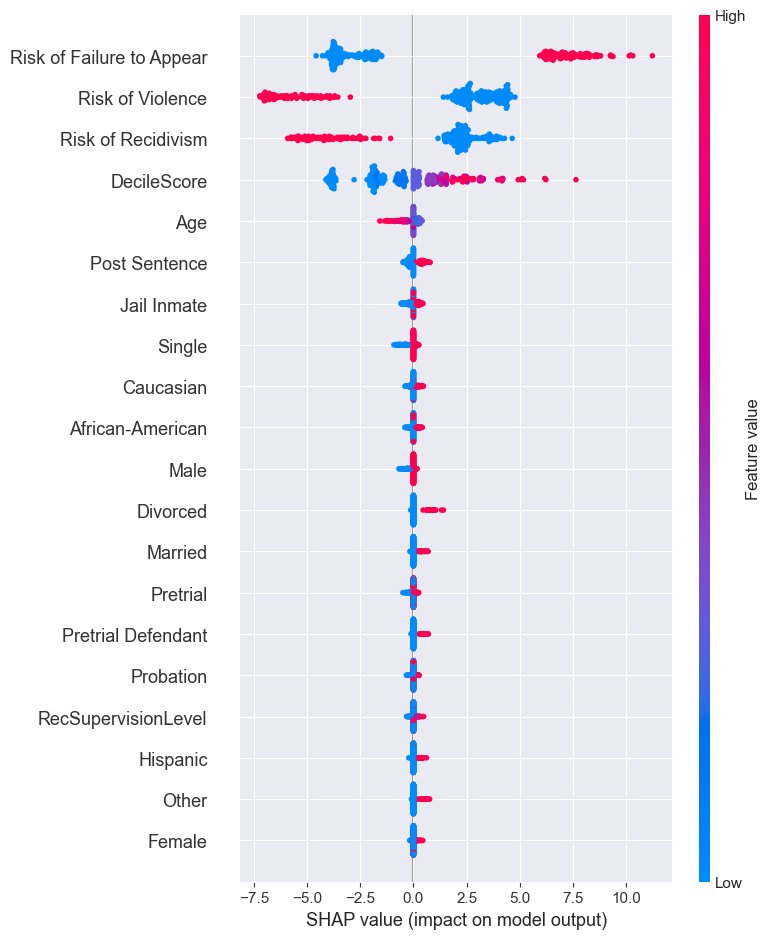

In [75]:
explainer = shap.KernelExplainer(model,shap.sample(X_test.iloc[:800, :], nsamples=300))
shap_values = explainer(X_test.iloc[1:300,:])
shap_values.values = shap_values.values.squeeze()
shap_values.base_values = shap_values.base_values.squeeze()
shap.summary_plot(shap_values = shap_values)
plt.show()

In [76]:
# X_test['African-Am']
X_test

,RecSupervisionLevel,DecileScore,Female,Male,African-American,Arabic,Asian,Caucasian,Hispanic,Native American,...,Married,Separated,Significant Other,Single,Unknown,Widowed,Risk of Failure to Appear,Risk of Recidivism,Risk of Violence,Age
50574,0.391810,0.927599,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,34.0
17242,-0.667274,-0.600383,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,36.0
27481,-0.667274,-0.982378,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,52.0
8908,-0.667274,0.545604,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,60.0
43357,-0.667274,-0.218387,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,47.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40607,-0.667274,0.163608,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,46.0
45496,-0.667274,-0.218387,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,34.0
30151,0.391810,1.309595,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,29.0
46757,-0.667274,-0.982378,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,33.0


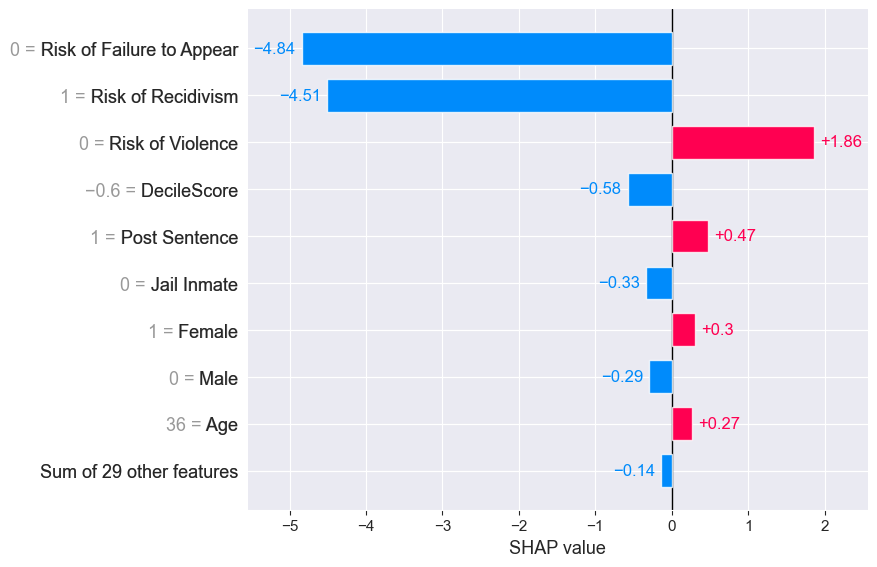

In [77]:
explainer = shap.KernelExplainer(model,X_test.iloc[:50, :])
shap_values = explainer(X_test.iloc[1,:])
shap_values.values = shap_values.values.squeeze()
shap_values.base_values = shap_values.base_values.squeeze()
# print(shap_values)
# shap.plots.waterfall(shap_values)
shap.plots.bar(shap_values = shap_values,max_display=10)

100%|██████████| 100/100 [00:08<00:00, 11.19it/s]


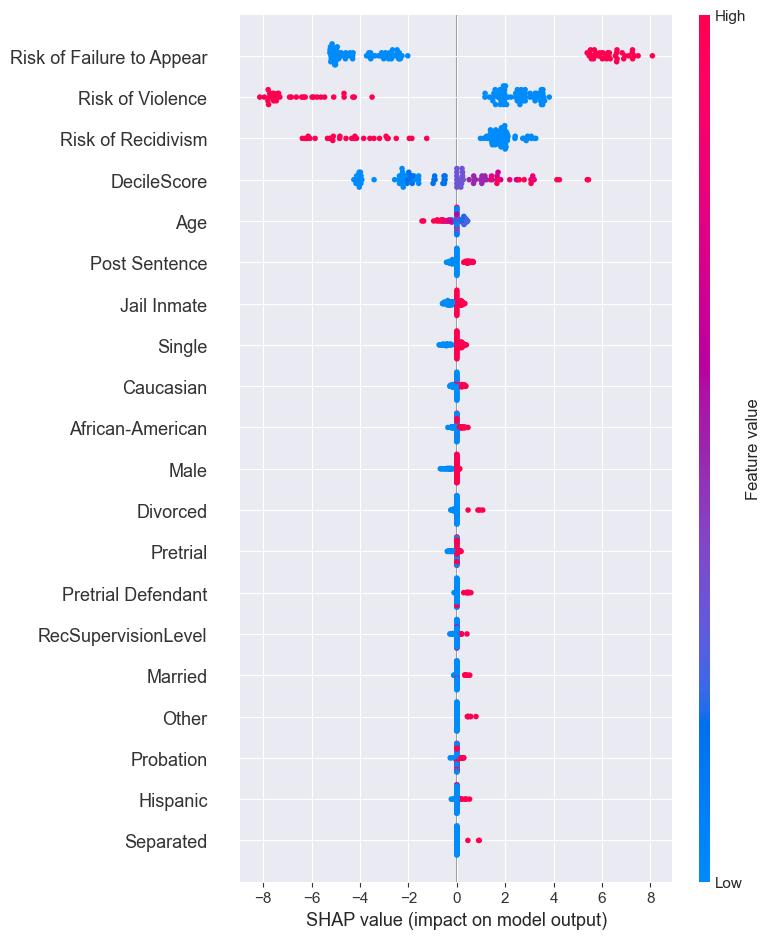

In [80]:
xplainer = shap.KernelExplainer(model,X_test.iloc[:50, :])
shap_values = explainer(X_test.iloc[100:200,:])
shap_values.values = shap_values.values.squeeze()
shap_values.base_values = shap_values.base_values.squeeze()
# print(shap_values)
shap.summary_plot(shap_values = shap_values)

In [79]:
np.array(X_test.iloc[0])

array([ 0.39181048,  0.9275991 ,  0.        ,  1.        ,  1.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  1.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  1.        ,
        0.        ,  1.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  1.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  1.        , 34.        ], dtype=float32)